[*********************100%***********************]  6 of 6 completed
[*********************100%***********************]  1 of 1 completed


<Figure size 1200x600 with 0 Axes>

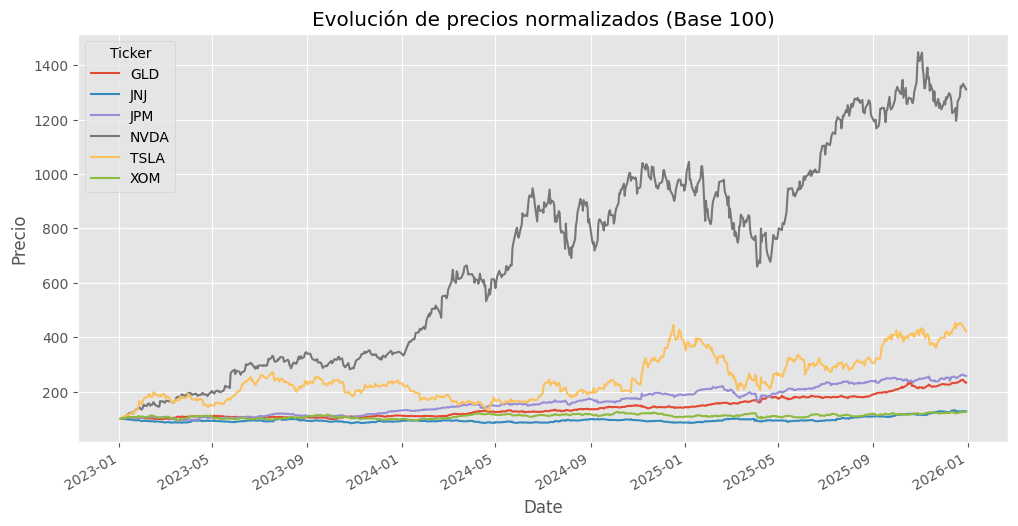

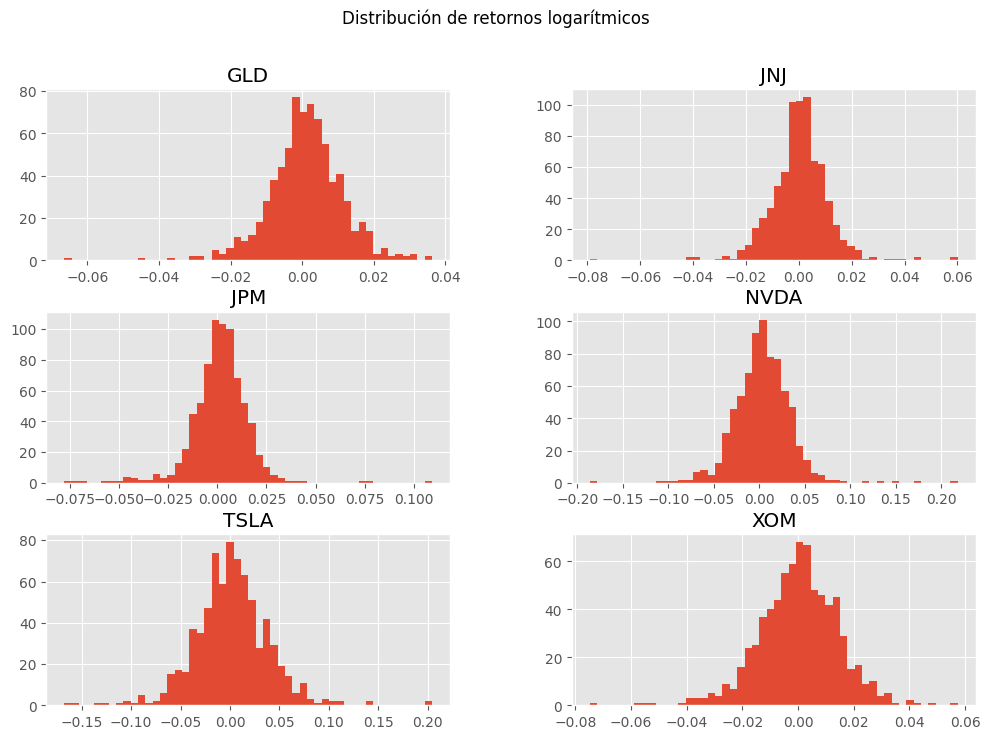

Activos procesados (6): ['GLD', 'JNJ', 'JPM', 'NVDA', 'TSLA', 'XOM']

 PESOS ÓPTIMOS
      Min Varianza  Max Sharpe
GLD         0.3000      0.3000
JNJ         0.3000      0.2562
JPM         0.1447      0.2316
NVDA        0.0659      0.2122
TSLA        0.0001      0.0000
XOM         0.1893      0.0000

MÉTRICAS
              Retorno esperado  Volatilidad  Ratio Sharpe
Min Varianza            0.2274       0.1086        1.7258
Max Sharpe              0.3632       0.1423        2.2719


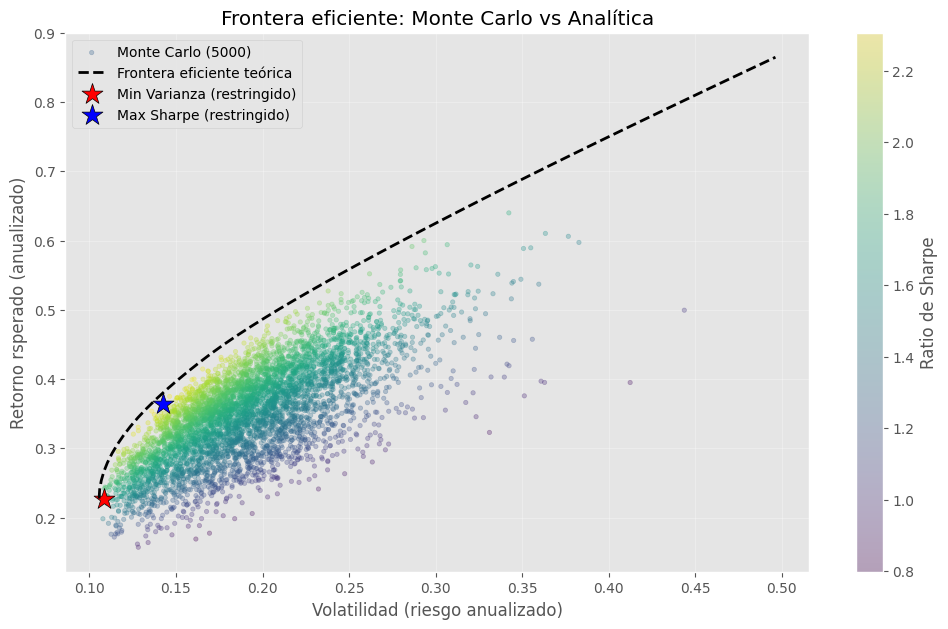


1. Retornos implícitos de equilibrio (prior) ---
Ticker
GLD     0.0136
JNJ     0.0081
JPM     0.0646
NVDA    0.1544
TSLA    0.2169
XOM     0.0362
dtype: float64

2. Matriz P (identificación de activos)
[[0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0. 0.]]

3. Vector Q (opiniones)
[[ 0.2 ]
 [ 0.3 ]
 [-0.05]]

4. Retornos posteriores (Black-Litterman)
Ticker
GLD    -0.0180
JNJ    -0.0007
JPM     0.0714
NVDA    0.2223
TSLA    0.2257
XOM     0.0331
dtype: float64

5. PESOS ÓPTIMOS BLACK-LITTERMAN
GLD     0.0
JNJ     0.0
JPM     0.3
NVDA    0.3
TSLA    0.3
XOM     0.1
Name: Pesos Black-Litterman, dtype: float64

MÉTRICAS BL
Retorno esperado: 0.1591
Volatilidad:      0.3124
Ratio Sharpe:     0.3814
Resultados CAPM para TSLA
Alpha (exceso de retorno autónomo): 0.00010
Beta (sensibilidad al mercado):     2.30594
R-cuadrado (Explicabilidad):        0.3386


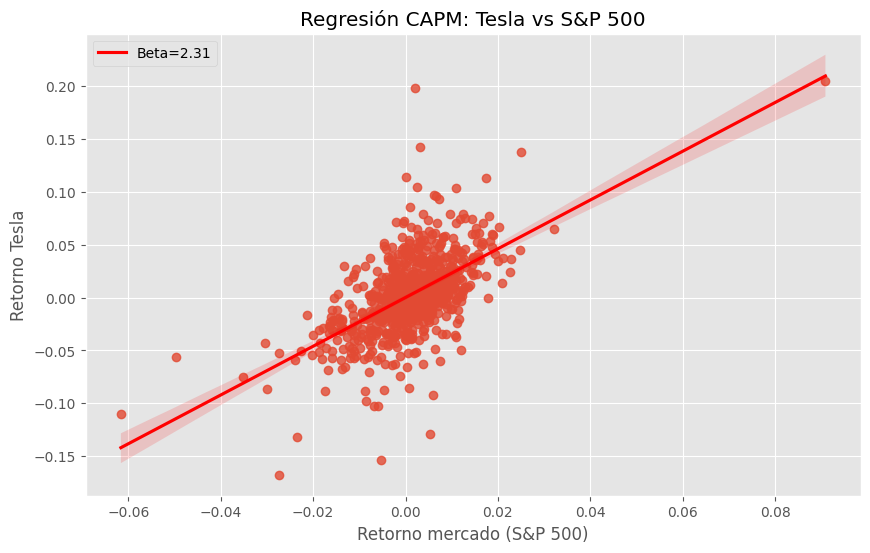


descarga Fama-French (3 Factores) ---
Factores descargados (Mkt-RF, SMB, HML).


/tmp/ipykernel_163/4131270988.py:316: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_data = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start=start_date, end=end_date)[0]
/tmp/ipykernel_163/4131270988.py:316: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_data = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start=start_date, end=end_date)[0]


,Mkt-RF,SMB,HML,RF
Date,,,,
2023-01,6.61,5.01,-3.94,0.35
2023-02,-2.57,1.05,-0.80,0.34
2023-03,2.48,-5.48,-9.05,0.36
2023-04,0.62,-3.37,-0.12,0.35
2023-05,0.34,1.60,-7.79,0.36



PESOS ÓPTIMOS (Min CVaR)
GLD     0.3000
JNJ     0.3000
JPM     0.1026
NVDA    0.0840
TSLA    0.0000
XOM     0.2134
Name: Min CVaR, dtype: float64
      Min Varianza  Max Sharpe  Black-Litterman  Min CVaR
GLD         0.3000      0.3000              0.0    0.3000
JNJ         0.3000      0.2562              0.0    0.3000
JPM         0.1447      0.2316              0.3    0.1026
NVDA        0.0659      0.2122              0.3    0.0840
TSLA        0.0001      0.0000              0.3    0.0000
XOM         0.1893      0.0000              0.1    0.2134


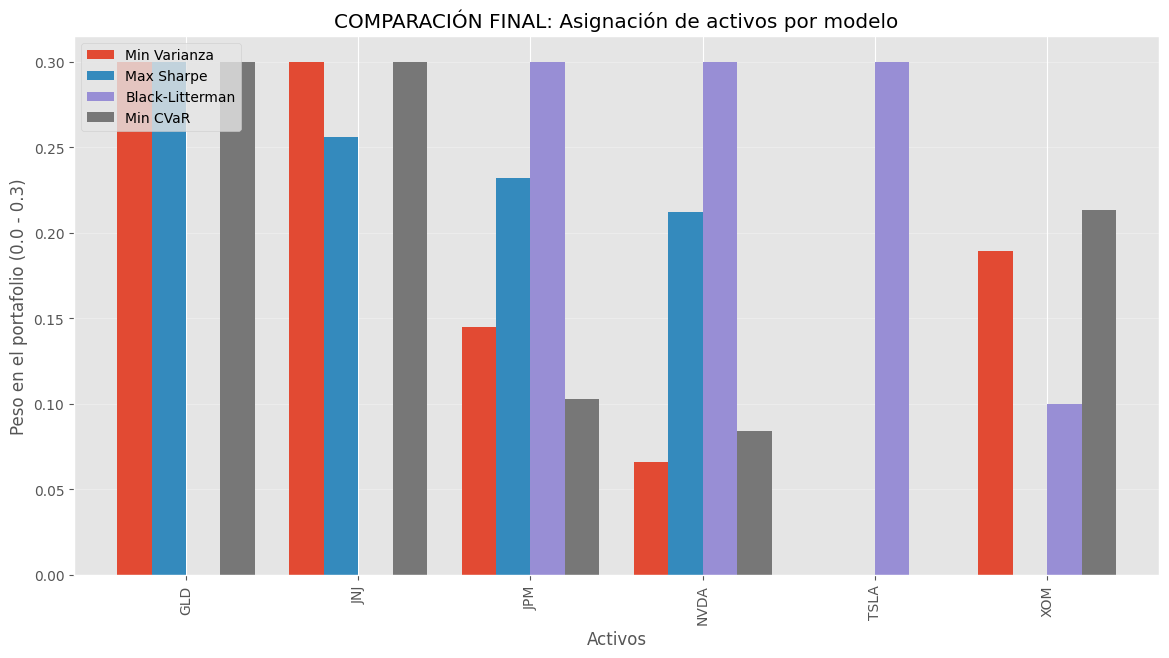

In [2]:
!pip install -q yfinance PyPortfolioOpt cvxpy matplotlib seaborn pandas numpy scipy statsmodels pandas_datareader

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cvxpy as cp
import statsmodels.api as sm
import pandas_datareader.data as web
from scipy import stats
from pypfopt import EfficientFrontier, risk_models, expected_returns
from pypfopt import black_litterman, BlackLittermanModel
from pypfopt import objective_functions

plt.style.use('ggplot')
np.random.seed(777)

#SECCIÓN 1: DESCARGA Y PREPARACIÓN DE DATOS

tickers = ['TSLA', 'NVDA', 'JPM', 'JNJ', 'XOM', 'GLD']
benchmark = '^GSPC' # S&P 500

#Periodo: 3 años
start_date = '2023-01-01'
end_date = '2025-12-31'

data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)['Adj Close']
market_data = yf.download(benchmark, start=start_date, end=end_date, auto_adjust=False)['Adj Close']

#Limpieza
data = data.dropna()
market_data = market_data.dropna()

#Retornos logarítmicos
log_returns = np.log(data / data.shift(1)).dropna()
market_log_returns = np.log(market_data / market_data.shift(1)).dropna()
#visualización de precios normalizados
plt.figure(figsize=(12, 6))
(data / data.iloc[0] * 100).plot(figsize=(12, 6))
plt.title('Evolución de precios normalizados (Base 100)')
plt.ylabel('Precio')
plt.show()
log_returns.hist(bins=50, figsize=(12, 8))
plt.suptitle('Distribución de retornos logarítmicos')
plt.show()

#1. Ajustamos los parámetros usando SOLAMENTE los activos que sí tienen datos
#Usamos .values para convertir a numpy y evitar errores de índice con Pandas
mu = log_returns.mean() * 252
Sigma = log_returns.cov() * 252

#Definimos n_assets basado en los datos reales, no en la lista inicial
n_assets = len(mu)
tickers_reales = log_returns.columns.tolist()

print(f"Activos procesados ({n_assets}): {tickers_reales}")

def solve_markowitz_cvxpy(mu_series, Sigma_df, target_return=None, mode='min_vol'):
    #convertimos a arrays de numpy para que CVXPY no se confunda con los índices
    mu_vals = mu_series.values
    Sigma_vals = Sigma_df.values

    w = cp.Variable(n_assets)
    risk = cp.quad_form(w, Sigma_vals)
    ret = mu_vals @ w

    #restricciones base: Suma=1, Long-only, Peso Max 30%
    constraints = [
        cp.sum(w) == 1,
        w >= 0,
        w <= 0.30
    ]

    if mode == 'min_vol':
        objective = cp.Minimize(risk)
    elif mode == 'max_sharpe':
        #aproximación cuadrática para Max Sharpe
        gamma = cp.Parameter(value=1.0)
        objective = cp.Maximize(ret - gamma * risk)

    prob = cp.Problem(objective, constraints)
    try:
        prob.solve()
        if w.value is None:
            print(f"Advertencia: El solver no convergió para {mode}.")
            return np.ones(n_assets) / n_assets
        return w.value
    except Exception as e:
        print(f"Error en optimización: {e}")
        return np.ones(n_assets) / n_assets

#A. Minima Varianza
w_min_vol = solve_markowitz_cvxpy(mu, Sigma, mode='min_vol')

#B. Máximo Sharpe (Usando PyPortfolioOpt)
#PyPortfolioOpt maneja mejor la estabilidad numérica para Sharpe
from pypfopt import EfficientFrontier

ef_sharpe = EfficientFrontier(mu, Sigma)
ef_sharpe.add_constraint(lambda w: w <= 0.30)
try:
    w_max_sharpe_dict = ef_sharpe.max_sharpe(risk_free_rate=0.04)
    w_max_sharpe = np.array([w_max_sharpe_dict[t] for t in tickers_reales])
except:
    print("Advertencia: PyPortfolioOpt falló, usando aproximación de CVXPY para Sharpe.")
    w_max_sharpe = solve_markowitz_cvxpy(mu, Sigma, mode='max_sharpe')

#DataFrame de resultados
weights_df = pd.DataFrame({
    'Min Varianza': w_min_vol,
    'Max Sharpe': w_max_sharpe
}, index=tickers_reales)

print("\n PESOS ÓPTIMOS")
print(weights_df.round(4))

#Cálculo de métricas para el cuadro final
#Retorno y volatilidad Min Varianza
ret_mv = w_min_vol @ mu.values
vol_mv = np.sqrt(w_min_vol.T @ Sigma.values @ w_min_vol)
sharpe_mv = (ret_mv - 0.04) / vol_mv

#Retorno y volatilidad Max Sharpe
ret_ms = w_max_sharpe @ mu.values
vol_ms = np.sqrt(w_max_sharpe.T @ Sigma.values @ w_max_sharpe)
sharpe_ms = (ret_ms - 0.04) / vol_ms

metrics_df = pd.DataFrame({
    'Retorno esperado': [ret_mv, ret_ms],
    'Volatilidad': [vol_mv, vol_ms],
    'Ratio Sharpe': [sharpe_mv, sharpe_ms]
}, index=['Min Varianza', 'Max Sharpe'])

print("\nMÉTRICAS")
print(metrics_df.round(4))

# SECCIÓN 3: FRONTERA EFICIENTE (analítica vs Monte Carlo)

#A. SIMULACIÓN MONTE CARLO (portafolios aleatorios)

n_sim = 5000
results_mc = np.zeros((3, n_sim))

#Usamos valores numpy puros para velocidad y seguridad
mu_vals = mu.values
Sigma_vals = Sigma.values
max_ret_asset = np.max(mu_vals) #retorno del activo más rentable

for i in range(n_sim):
    #generar pesos aleatorios
    weights = np.random.random(n_assets)
    weights /= np.sum(weights) #normalizar a 1

    #calcular retorno y riesgo
    p_ret = np.dot(weights, mu_vals)
    p_vol = np.sqrt(np.dot(weights.T, np.dot(Sigma_vals, weights)))
    p_sharpe = (p_ret - 0.04) / p_vol #asumimos tasa libre 4%

    results_mc[0,i] = p_ret
    results_mc[1,i] = p_vol
    results_mc[2,i] = p_sharpe

# B. FRONTERA EFICIENTE ANALÍTICA
#definimos 50 objetivos de retorno entre el Min Varianza y el activo más rentable
target_rets = np.linspace(ret_mv, max_ret_asset, 50)
efficient_vols = []

for tr in target_rets:
    #resolvemos Min volatilidad para cada retorno objetivo
    w_target = cp.Variable(n_assets)
    risk = cp.quad_form(w_target, Sigma_vals)

    constraints = [
        cp.sum(w_target) == 1,
        w_target >= 0,
        w_target <= 1.0, #relajamos la restricción del 30% para ver la frontera teórica completa
        mu_vals @ w_target >= tr
    ]

    prob = cp.Problem(cp.Minimize(risk), constraints)
    try:
        prob.solve()
        efficient_vols.append(np.sqrt(prob.value))
    except:
        efficient_vols.append(None) # Si no hay solución factible


plt.figure(figsize=(12, 7))

#1. Monte Carlo (Nube)
plt.scatter(results_mc[1,:], results_mc[0,:], c=results_mc[2,:],
            cmap='viridis', alpha=0.3, s=10, label='Monte Carlo (5000)')
plt.colorbar(label='Ratio de Sharpe')

#2. Frontera analítica (línea)
plt.plot(efficient_vols, target_rets, 'k--', linewidth=2, label='Frontera eficiente teórica')

#3. Puntos óptimos (estrellas)
plt.scatter(vol_mv, ret_mv, c='red', s=250, marker='*', edgecolors='black', label='Min Varianza (restringido)')
plt.scatter(vol_ms, ret_ms, c='blue', s=250, marker='*', edgecolors='black', label='Max Sharpe (restringido)')

plt.title('Frontera eficiente: Monte Carlo vs Analítica')
plt.xlabel('Volatilidad (riesgo anualizado)')
plt.ylabel('Retorno rsperado (anualizado)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

#SECCIÓN 4 FINAL: MODELO BLACK-LITTERMAN

from pypfopt import black_litterman, BlackLittermanModel
from pypfopt import EfficientFrontier

#Definir los parámetros del mercado (prior)
delta = 2.5
mcaps = {t: 1.0 for t in tickers_reales} #pesos iguales (1/N)

market_prior = black_litterman.market_implied_prior_returns(
    market_caps=mcaps,
    risk_aversion=delta,
    cov_matrix=Sigma
)

print("\n1. Retornos implícitos de equilibrio (prior) ---")
print(market_prior.round(4))

#2. definir las opiniones del inversionista (views)
viewdict = {
    'TSLA': 0.20,  #optimista en Tesla
    'NVDA': 0.30,    #es la líder de IA, asumimos que subirá fuerte (+30%)
    'GLD': -0.05   #bajista en Oro

}

#3. Construir el modelo
bl = BlackLittermanModel(Sigma, pi=market_prior, absolute_views=viewdict)

print("\n2. Matriz P (identificación de activos)")
print(bl.P)
print("\n3. Vector Q (opiniones)")
print(bl.Q)

#4. Calcular retornos posteriores
ret_bl = bl.bl_returns()
cov_bl = bl.bl_cov()

print("\n4. Retornos posteriores (Black-Litterman)")
print(ret_bl.round(4))

#5. Optimización del portafolio BL
ef_bl = EfficientFrontier(ret_bl, cov_bl)
ef_bl.add_constraint(lambda w: w <= 0.30)
ef_bl.add_constraint(lambda w: w >= 0)
ef_bl.add_constraint(lambda w: cp.sum(w) == 1)

try:
    w_bl_dict = ef_bl.max_sharpe(risk_free_rate=0.04)
    w_bl = np.array([w_bl_dict[t] for t in tickers_reales])
except:
    print("Advertencia: Falló Max Sharpe BL, usando Min Volatilidad.")
    w_bl_dict = ef_bl.min_volatility()
    w_bl = np.array([w_bl_dict[t] for t in tickers_reales])

# 6. Mostrar Resultados
weights_bl_df = pd.Series(w_bl, index=tickers_reales, name="Pesos Black-Litterman")

print("\n5. PESOS ÓPTIMOS BLACK-LITTERMAN")
print(weights_bl_df.round(4))

#Métricas BL
ret_bl_port = w_bl @ ret_bl.values
vol_bl_port = np.sqrt(w_bl.T @ cov_bl.values @ w_bl)
sharpe_bl = (ret_bl_port - 0.04) / vol_bl_port

print("\nMÉTRICAS BL")
print(f"Retorno esperado: {ret_bl_port:.4f}")
print(f"Volatilidad:      {vol_bl_port:.4f}")
print(f"Ratio Sharpe:     {sharpe_bl:.4f}")

#SECCIÓN 5: CAPM Y MODELOS DE FACTORES

#5.1 Regresión CAPM para TSLA (activo más volátil del portafolio)
#Alinear fechas entre el activo y el mercado
asset_ret = log_returns['TSLA']
common_idx = asset_ret.index.intersection(market_log_returns.index)
y = asset_ret.loc[common_idx] #retorno Tesla
x = market_log_returns.loc[common_idx] #retorno mercado (S&P500)

#Regresión lineal (OLS)
X_sm = sm.add_constant(x) #agregar constante (Alpha)
model_capm = sm.OLS(y, X_sm).fit()

alpha_tsla = model_capm.params.iloc[0]
beta_tsla = model_capm.params.iloc[1]
r_squared = model_capm.rsquared

print(f"Resultados CAPM para TSLA")
print(f"Alpha (exceso de retorno autónomo): {alpha_tsla:.5f}")
print(f"Beta (sensibilidad al mercado):     {beta_tsla:.5f}")
print(f"R-cuadrado (Explicabilidad):        {r_squared:.4f}")

#Gráfico de regresión
plt.figure(figsize=(10, 6))
sns.regplot(x=x, y=y, line_kws={"color": "red", "label": f"Beta={beta_tsla:.2f}"})
plt.title('Regresión CAPM: Tesla vs S&P 500')
plt.xlabel('Retorno mercado (S&P 500)')
plt.ylabel('Retorno Tesla')
plt.legend()
plt.show()

#5.2  Fama-French
print("\ndescarga Fama-French (3 Factores) ---")
try:
    # Usamos pandas_datareader
    ff_data = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start=start_date, end=end_date)[0]
    print("Factores descargados (Mkt-RF, SMB, HML).")
    display(ff_data.head())
except:
    print("Nota: No se pudo conectar a la librería de Kenneth French.")
    print("")

#SECCIÓN 6: OPTIMIZACIÓN AVANZADA (CVaR - Minimizar Pérdidas Extremas)

#Configuración CVaR (95% de confianza)
beta_conf = 0.95
scenarios = log_returns.values #matriz de escenarios históricos
T_scen, N_assets = scenarios.shape

#Variables de decisión CVXPY
w_cvar = cp.Variable(N_assets)
VaR = cp.Variable()
z = cp.Variable(T_scen)

#Función objetivo: minimizar CVaR
#CVaR = VaR + (1 / ((1-beta) * T)) * sum(z)
objective_cvar = cp.Minimize(VaR + (1 / ((1 - beta_conf) * T_scen)) * cp.sum(z))

#Restricciones
constraints_cvar = [
    cp.sum(w_cvar) == 1,   #Presupuesto
    w_cvar >= 0,           #Long only
    w_cvar <= 0.30,        #Diversificación máx 30%
    z >= 0,                #Variable auxiliar positiva
    z >= -scenarios @ w_cvar - VaR #Pérdida > VaR
]

#Resolver
prob_cvar = cp.Problem(objective_cvar, constraints_cvar)
try:
    prob_cvar.solve()
    w_cvar_val = w_cvar.value
except:
    print("El solver falló, asignando pesos equitativos.")
    w_cvar_val = np.ones(N_assets)/N_assets

w_cvar_series = pd.Series(w_cvar_val, index=tickers_reales, name="Min CVaR")
print("\nPESOS ÓPTIMOS (Min CVaR)")
print(w_cvar_series.round(4))

#7. COMPARACIÓN FINAL

#Unimos todos los portafolios calculados
final_df = pd.DataFrame({
    'Min Varianza': w_min_vol,      #seguro
    'Max Sharpe': w_max_sharpe,     #eficiente
    'Black-Litterman': w_bl,        #subjetivo (Tus views)
    'Min CVaR': w_cvar_val          #robusto (Anti-crisis)
}, index=tickers_reales)

print(final_df.round(4))

#Gráfico
final_df.plot(kind='bar', figsize=(14, 7), width=0.8)
plt.title('COMPARACIÓN FINAL: Asignación de activos por modelo')
plt.ylabel('Peso en el portafolio (0.0 - 0.3)')
plt.xlabel('Activos')
plt.legend(loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.show()